# Logistic Regression: Comprehensive Guide to Loss Function (Binary Cross-Entropy)

## 1. Introduction
Logistic Regression is a foundational classification algorithm used to estimate the probability that an instance belongs to a specific class (e.g., binary outcome 0 or 1). 

Unlike Linear Regression which uses **Mean Squared Error (MSE)**, Logistic Regression uses **Binary Cross-Entropy Loss** (also known as **Log Loss**).

---

## 2. Mathematical Formulation

### A. Prediction Model (Hypothesis)
Given input vector $\mathbf{x} \in \mathbb{R}^d$, weights $\mathbf{w}$, and bias $b$:
$$z = \mathbf{w}^T \mathbf{x} + b$$

The prediction $\hat{y}$ is the probability estimated by passing $z$ through the **Sigmoid function**:
$$\hat{y} = P(y=1 \mid \mathbf{x}) = \sigma(z) = \frac{1}{1 + e^{-z}}$$

### B. Single-Sample Loss Function
For a single sample with true label $y \in \{0, 1\}$ and predicted probability $\hat{y} \in (0, 1)$:
$$\mathcal{L}(\hat{y}, y) = -\left[ y \log(\hat{y}) + (1 - y) \log(1 - \hat{y}) \right]$$

### C. Cost Function over $m$ Samples
The overall Cost Function $J(\mathbf{w}, b)$ is the average loss across all $m$ training samples:
$$J(\mathbf{w}, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

---

## 3. Derivation from Maximum Likelihood Estimation (MLE)
The label $y \in \{0, 1\}$ follows a Bernoulli distribution:
$$P(y \mid \mathbf{x}) = \hat{y}^y (1 - \hat{y})^{1 - y}$$

For $m$ independent samples, the Likelihood $L(\mathbf{w}, b)$ is:
$$L(\mathbf{w}, b) = \prod_{i=1}^{m} (\hat{y}^{(i)})^{y^{(i)}} (1 - \hat{y}^{(i)})^{1 - y^{(i)}}$$

Taking the natural logarithm yields the Log-Likelihood:
$$\log L(\mathbf{w}, b) = \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

Minimizing the **Negative Log-Likelihood (NLL)** averaged over $m$ samples gives the standard Log Loss cost function:
$$J(\mathbf{w}, b) = -\frac{1}{m} \log L(\mathbf{w}, b)$$


## Section 1: Visualizing Loss Behavior & Convexity

Let's explore why Log Loss is suitable for classification and why MSE fails with Sigmoid activation.


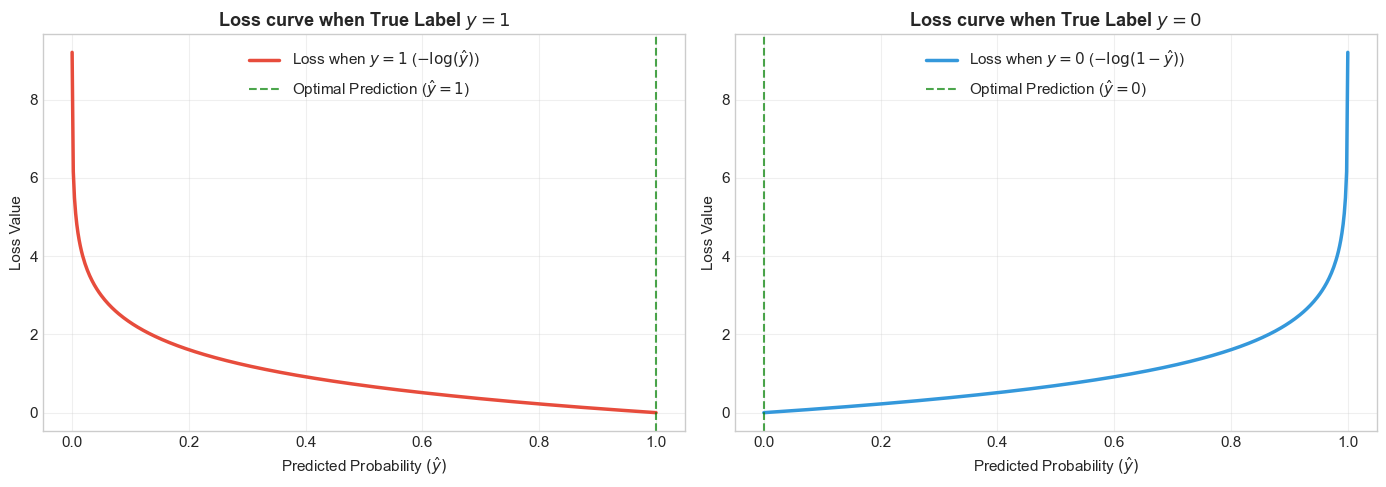

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11

# Avoid log(0) domain error by clipping predictions slightly
y_hat = np.linspace(0.0001, 0.9999, 500)

# Calculate loss for y = 1 and y = 0
loss_y1 = -np.log(y_hat)
loss_y0 = -np.log(1 - y_hat)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot for y = 1
ax[0].plot(y_hat, loss_y1, color='#e74c3c', linewidth=2.5, label=r'Loss when $y = 1$ ($-\log(\hat{y})$)')
ax[0].set_title('Loss curve when True Label $y = 1$', fontsize=13, fontweight='bold')
ax[0].set_xlabel('Predicted Probability $(\hat{y})$')
ax[0].set_ylabel('Loss Value')
ax[0].axvline(1.0, color='green', linestyle='--', alpha=0.7, label='Optimal Prediction ($\hat{y}=1$)')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Plot for y = 0
ax[1].plot(y_hat, loss_y0, color='#3498db', linewidth=2.5, label=r'Loss when $y = 0$ ($-\log(1-\hat{y})$)')
ax[1].set_title('Loss curve when True Label $y = 0$', fontsize=13, fontweight='bold')
ax[1].set_xlabel('Predicted Probability $(\hat{y})$')
ax[1].set_ylabel('Loss Value')
ax[1].axvline(0.0, color='green', linestyle='--', alpha=0.7, label='Optimal Prediction ($\hat{y}=0$)')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Log Loss vs. MSE Convexity Surface
When paired with the Sigmoid activation, MSE produces a **non-convex** surface full of local minima and flat regions where gradients stall. Log Loss yields a **convex** bowl shape guaranteed to have a single global minimum.


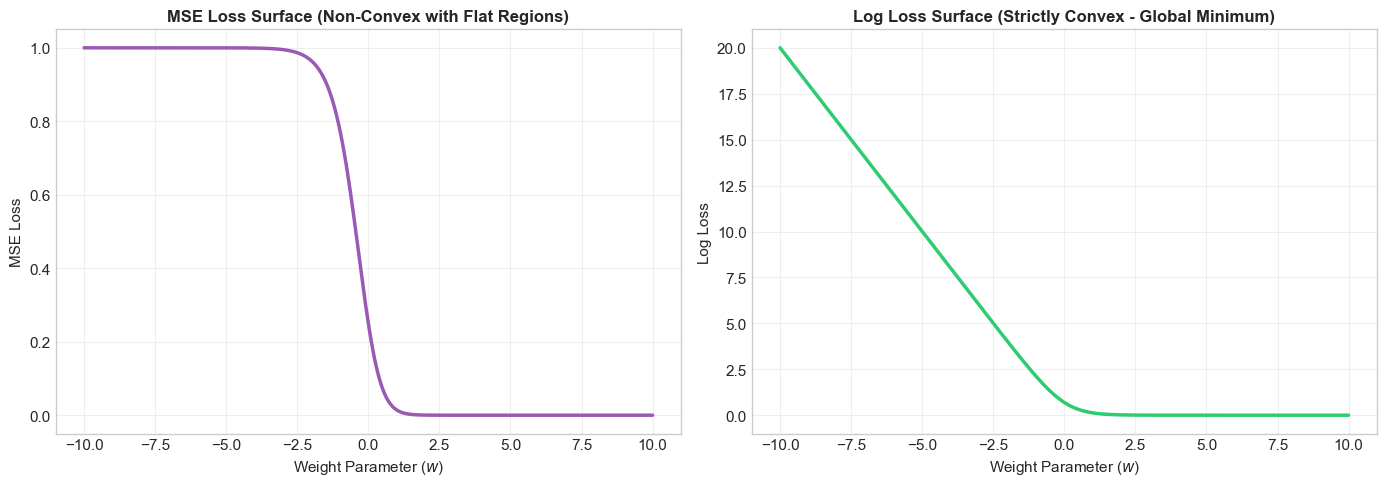

In [2]:
w_vals = np.linspace(-10, 10, 300)

# Synthetic sample: x = 2, true y = 1
x_sample = 2.0
y_sample = 1.0

# Prediction for each weight z = w * x
z_vals = w_vals * x_sample
y_hat_vals = 1 / (1 + np.exp(-z_vals))

# Calculate MSE Loss and Log Loss
mse_loss = (y_sample - y_hat_vals)**2
log_loss = - (y_sample * np.log(y_hat_vals) + (1 - y_sample) * np.log(1 - y_hat_vals))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot MSE Loss
ax[0].plot(w_vals, mse_loss, color='#9b59b6', linewidth=2.5)
ax[0].set_title('MSE Loss Surface (Non-Convex with Flat Regions)', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Weight Parameter ($w$)')
ax[0].set_ylabel('MSE Loss')
ax[0].grid(True, alpha=0.3)

# Plot Log Loss
ax[1].plot(w_vals, log_loss, color='#2ecc71', linewidth=2.5)
ax[1].set_title('Log Loss Surface (Strictly Convex - Global Minimum)', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Weight Parameter ($w$)')
ax[1].set_ylabel('Log Loss')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Section 2: Implementing Logistic Regression & Gradient Descent from Scratch

We build a custom Python class `CustomLogisticRegression` to demonstrate how gradients are derived and weights are updated using Gradient Descent.

### Gradient Equations:
$$\frac{\partial J}{\partial \mathbf{w}} = \frac{1}{m} \mathbf{X}^T (\mathbf{\hat{y}} - \mathbf{y})$$

$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})$$


In [3]:
class CustomLogisticRegression:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.loss_history = []
        
    def _sigmoid(self, z):
        z_clipped = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z_clipped))
    
    def compute_loss(self, y_true, y_pred):
        m = len(y_true)
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        loss = - (1 / m) * np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        return loss
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []
        
        for epoch in range(self.epochs):
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self._sigmoid(linear_model)
            
            loss = self.compute_loss(y, y_pred)
            self.loss_history.append(loss)
            
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)
            
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_model)
    
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


## Section 3: Practical Application on Diabetes Dataset (`diabetes.csv`)

Now we test our custom implementation on the `diabetes.csv` dataset present in the workspace, compare loss reduction over epochs, and benchmark against Scikit-Learn.


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, log_loss, confusion_matrix, roc_curve, auc

# Load dataset
df = pd.read_csv('diabetes.csv')
print(f"Dataset Shape: {df.shape}")
display(df.head())

# Features & Target
X = df.drop(columns=['Outcome']).values
y = df['Outcome'].values

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Custom Model
custom_model = CustomLogisticRegression(learning_rate=0.1, epochs=1500)
custom_model.fit(X_train_scaled, y_train)

# Train Scikit-Learn Model
sklearn_model = LogisticRegression(random_state=42)
sklearn_model.fit(X_train_scaled, y_train)

print("Training Complete.")
print(f"Custom Model Final Training Loss: {custom_model.loss_history[-1]:.4f}")


Dataset Shape: (2000, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0


Training Complete.
Custom Model Final Training Loss: 0.4821


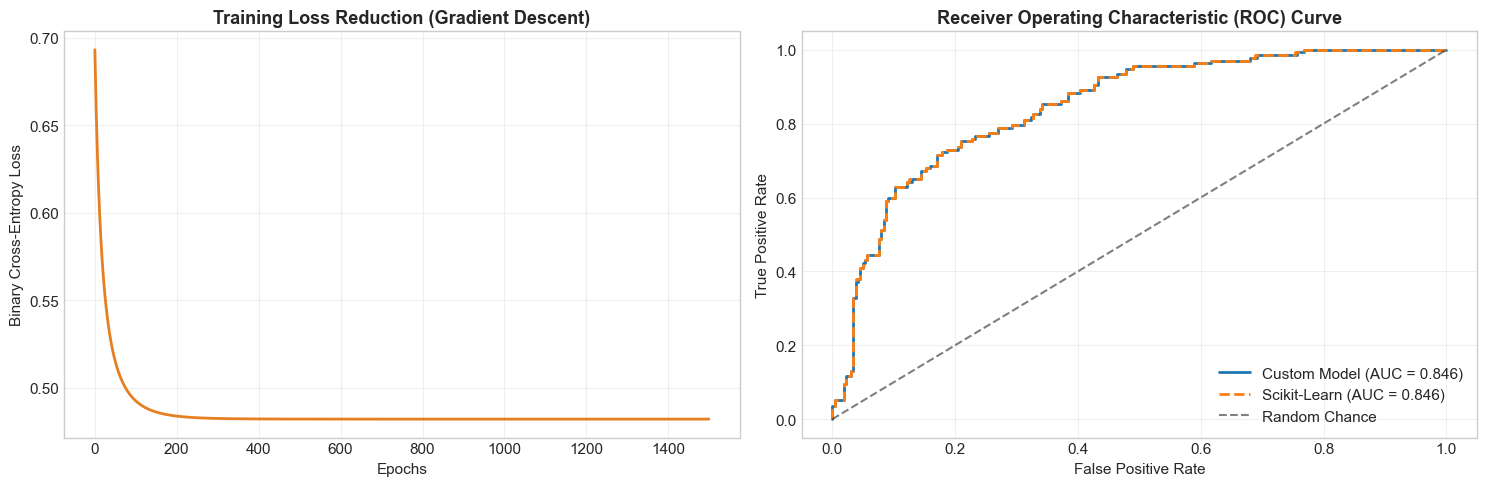

CUSTOM LOGISTIC REGRESSION MODEL TEST METRICS:
Test Log Loss: 0.4691
Test Accuracy: 80.25%

Classification Report (Custom Model):
                 precision    recall  f1-score   support

No Diabetes (0)       0.81      0.91      0.86       263
   Diabetes (1)       0.77      0.60      0.67       137

       accuracy                           0.80       400
      macro avg       0.79      0.75      0.77       400
   weighted avg       0.80      0.80      0.80       400



In [5]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Loss Reduction Curve
ax[0].plot(custom_model.loss_history, color='#e67e22', linewidth=2)
ax[0].set_title('Training Loss Reduction (Gradient Descent)', fontsize=13, fontweight='bold')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Binary Cross-Entropy Loss')
ax[0].grid(True, alpha=0.3)

# Evaluate Test Performance
y_pred_custom = custom_model.predict(X_test_scaled)
y_prob_custom = custom_model.predict_proba(X_test_scaled)

y_pred_sklearn = sklearn_model.predict(X_test_scaled)
y_prob_sklearn = sklearn_model.predict_proba(X_test_scaled)[:, 1]

# ROC Curves
fpr_custom, tpr_custom, _ = roc_curve(y_test, y_prob_custom)
fpr_sk, tpr_sk, _ = roc_curve(y_test, y_prob_sklearn)

ax[1].plot(fpr_custom, tpr_custom, label=f'Custom Model (AUC = {auc(fpr_custom, tpr_custom):.3f})', linewidth=2)
ax[1].plot(fpr_sk, tpr_sk, label=f'Scikit-Learn (AUC = {auc(fpr_sk, tpr_sk):.3f})', linestyle='--', linewidth=2)
ax[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Chance')
ax[1].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=13, fontweight='bold')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print Comparison Metrics
print("="*50)
print("CUSTOM LOGISTIC REGRESSION MODEL TEST METRICS:")
print(f"Test Log Loss: {log_loss(y_test, y_prob_custom):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_custom)*100:.2f}%")
print("\nClassification Report (Custom Model):")
print(classification_report(y_test, y_pred_custom, target_names=['No Diabetes (0)', 'Diabetes (1)']))


## Section 4: Summary Table

| Concept | Linear Regression | Logistic Regression |
| :--- | :--- | :--- |
| **Output Type** | Continuous ($\mathbb{R}$) | Probabilistic ($[0, 1]$) |
| **Activation Function** | Identity ($z = \mathbf{w}^T\mathbf{x}+b$) | Sigmoid ($\sigma(z) = \frac{1}{1+e^{-z}}$) |
| **Loss Function** | Mean Squared Error (MSE) | Binary Cross-Entropy (Log Loss) |
| **Loss Equation** | $\frac{1}{2m}\sum(\hat{y}-y)^2$ | $-\frac{1}{m}\sum [y\log\hat{y} + (1-y)\log(1-\hat{y})]$ |
| **Optimization Surface** | Convex (Quadratic) | Convex (with Sigmoid + Log Loss) |
| **Gradient Formula** | $\frac{1}{m}\mathbf{X}^T(\mathbf{\hat{y}}-\mathbf{y})$ | $\frac{1}{m}\mathbf{X}^T(\mathbf{\hat{y}}-\mathbf{y})$ |
